# JEPA v2 Surface-Feature Diagnostics

This notebook probes whether the JEPA v2 encoder linearly exposes simple sequence statistics more strongly than state-dependent Othello features.

Assumptions checked from the repository:
- Legal move count uses `OthelloBoardState.get_valid_moves()`, with implicit pass handling for the next effective side to move.
- `dataset.py::load_chunk` returns raw board-cell move lists, directly usable by `OthelloBoardState`.
- In this repo `OthelloJEPA` lives in `othello_research.objectives.jepa`; use `context_encoder` as the inner GPT encoder.


## 1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configure Paths

In [22]:
from pathlib import Path
import os
import subprocess
import sys

# Single configuration cell: change these for another encoder checkpoint.
BOARD_SIZE = 8
JEPA_RUN_NAME = 'jepa_v3_mlp_k8_b8_run_001'
N_TRAIN_CHUNKS = 50

PROJECT_ROOT_CANDIDATES = [
    Path('/content/drive/Othercomputers/MyLaptop/Master_Thesis_Code'),
    Path('/content/drive/MyDrive/Master_Thesis_Code'),
]
PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if (p / 'pyproject.toml').exists()), PROJECT_ROOT_CANDIDATES[-1])
ARTIFACT_ROOT = Path('/content/drive/MyDrive/Master_Thesis_Artifacts')

DATA_CANDIDATES = [
    PROJECT_ROOT / 'data' / f'othello_{BOARD_SIZE}x{BOARD_SIZE}',
    ARTIFACT_ROOT / 'data' / f'othello_{BOARD_SIZE}x{BOARD_SIZE}',
]
DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), DATA_CANDIDATES[0])

RUN_CANDIDATES = [
    PROJECT_ROOT / 'runs' / JEPA_RUN_NAME,
    ARTIFACT_ROOT / 'runs' / JEPA_RUN_NAME,
]
JEPA_OUT_DIR = next((p for p in RUN_CANDIDATES if p.exists()), RUN_CANDIDATES[0])
RUNS_DIR = JEPA_OUT_DIR.parent

assert PROJECT_ROOT.exists(), PROJECT_ROOT
assert DATA_DIR.exists(), DATA_DIR
assert JEPA_OUT_DIR.exists(), JEPA_OUT_DIR
DIAG_OUT_DIR = JEPA_OUT_DIR / 'diagnostics'
DIAG_OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(PROJECT_ROOT)], check=True)
os.chdir(PROJECT_ROOT)

all_chunks = sorted(DATA_DIR.glob('*.pickle'))
assert len(all_chunks) > N_TRAIN_CHUNKS, f'Need validation chunks after first {N_TRAIN_CHUNKS}: {DATA_DIR}'
train_chunks = all_chunks[:N_TRAIN_CHUNKS]
val_chunks = all_chunks[-38:]

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR    :', DATA_DIR)
print('RUNS_DIR    :', RUNS_DIR)
print('JEPA_OUT_DIR:', JEPA_OUT_DIR)
print('DIAG_OUT_DIR:', DIAG_OUT_DIR)
print('train chunks:', len(train_chunks), 'val chunks:', len(val_chunks))

PROJECT_ROOT: /content/drive/Othercomputers/MyLaptop/Master_Thesis_Code
DATA_DIR    : /content/drive/MyDrive/Master_Thesis_Artifacts/data/othello_8x8
RUNS_DIR    : /content/drive/MyDrive/Master_Thesis_Artifacts/runs
JEPA_OUT_DIR: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v3_mlp_k8_b8_run_001
DIAG_OUT_DIR: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v3_mlp_k8_b8_run_001/diagnostics
train chunks: 50 val chunks: 38


## 3. Pick Checkpoint

In [23]:
checkpoint_files = sorted(JEPA_OUT_DIR.glob('*.pt'))
print('Checkpoint dir:', JEPA_OUT_DIR)
print('Available checkpoint files:')
for path in checkpoint_files:
    print(' ', path.name)

CHECKPOINT_NAME = 'final.pt'
CHECKPOINT_PATH = JEPA_OUT_DIR / CHECKPOINT_NAME
if not CHECKPOINT_PATH.exists():
    assert checkpoint_files, f'No checkpoint files found in {JEPA_OUT_DIR}'
    CHECKPOINT_PATH = checkpoint_files[-1]
print('Selected:', CHECKPOINT_PATH)

Checkpoint dir: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v3_mlp_k8_b8_run_001
Available checkpoint files:
  checkpoint_games_001M.pt
  checkpoint_games_005M.pt
  checkpoint_games_010M.pt
  checkpoint_games_015M.pt
  final.pt
  latest.pt
Selected: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v3_mlp_k8_b8_run_001/final.pt


## 4. Imports

In [24]:
import json
import math

import matplotlib.pyplot as plt
import torch

from othello_research.datasets.dataset import load_chunk
from othello_research.datasets.move_mapping import build_mappings
import othello_research.training.train_jepa as tjm
from othello_research.probes.surface_features import (
    FEATURE_SPECS,
    ProbeTrainConfig,
    extract_activations,
    run_surface_diagnostics,
)

print('imports OK')

imports OK


## 5. Restore Checkpoint And Load Model

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
jepa_model, jepa_cfg = tjm.build_model_from_checkpoint(ckpt)
state = ckpt['model']
load_mode = 'full_state_dict'

try:
    jepa_model.load_state_dict(state)
except RuntimeError as exc:
    # Legacy JEPA checkpoints before the unified objective refactor stored the
    # online encoder under `encoder.*` and may not contain target_encoder.* keys.
    # Surface diagnostics only probe the frozen online/context encoder, so load
    # that encoder directly and ignore predictor/target mismatches.
    if not any(key.startswith('encoder.') for key in state):
        raise
    encoder_state = {
        key.replace('encoder.', '', 1): value
        for key, value in state.items()
        if key.startswith('encoder.')
    }
    encoder = getattr(jepa_model, 'encoder', None)
    if encoder is None:
        encoder = jepa_model.context_encoder
    encoder.load_state_dict(encoder_state, strict=True)
    load_mode = 'legacy_encoder_only'

jepa_model.to(device)
jepa_model.eval()

encoder = getattr(jepa_model, 'encoder', None)
if encoder is None:
    encoder = jepa_model.context_encoder
encoder.to(device)
encoder.eval()

param_count = sum(p.numel() for p in encoder.parameters())
print('device     :', device)
print('checkpoint :', CHECKPOINT_PATH.name)
print('load mode  :', load_mode)
print('step       :', ckpt.get('step'))
print('games_seen :', f"{ckpt.get('games_seen', 0):,}")
print('encoder params:', f'{param_count:,}')
print('predictor  :', getattr(jepa_cfg, 'predictor_type', None))
print('horizon/EMA:', getattr(jepa_cfg, 'prediction_horizon', None), getattr(jepa_cfg, 'ema_momentum', None))


device     : cuda
checkpoint : final.pt
load mode  : full_state_dict
step       : 39200
games_seen : 19,999,840
encoder params: 25,312,768
predictor  : mlp
horizon/EMA: 8 0.99


## 6. Sanity Check

In [26]:
raw_to_token, _ = build_mappings(BOARD_SIZE)
first_game = load_chunk(str(train_chunks[0]))[0]
seq_len = min(8, encoder.config.block_size, len(first_game))
tokens = [raw_to_token[int(move)] for move in first_game[:seq_len]]
x = torch.tensor([tokens], dtype=torch.long, device=device)
pos = torch.tensor([seq_len - 1], dtype=torch.long, device=device)
acts = extract_activations(encoder, x, pos, layers=(len(encoder.blocks),))
print('input shape             :', tuple(x.shape))
print('last hidden state shape :', tuple(acts[len(encoder.blocks)].shape))

input shape             : (1, 8)
last hidden state shape : (1, 512)


## 7. Configure Diagnostic Run

In [27]:
DIAG_TRAIN_GAMES = 20000
DIAG_VAL_GAMES = 2000
DIAG_LAYERS = tuple(range(len(encoder.blocks) + 1))
DIAG_FEATURES = (
    'ply_index', 'parity', 'n_occupied', 'n_legal_moves',
    'last_move_position', 'corner_occupancy', 'edge_occupancy',
)
DIAG_SAMPLE_POSITIONS = 'one_per_game'

probe_cfg = ProbeTrainConfig(
    epochs=20,
    batch_size=256,
    lr=1e-3,
    weight_decay=0.0,
    device=str(device),
)

print('layers  :', DIAG_LAYERS)
print('features:', DIAG_FEATURES)
print('sample  :', DIAG_SAMPLE_POSITIONS)

layers  : (0, 1, 2, 3, 4, 5, 6, 7, 8)
features: ('ply_index', 'parity', 'n_occupied', 'n_legal_moves', 'last_move_position', 'corner_occupancy', 'edge_occupancy')
sample  : one_per_game


## 8. Run Diagnostics

In [28]:
results = run_surface_diagnostics(
    encoder=encoder,
    train_chunks=train_chunks,
    val_chunks=val_chunks,
    board_size=BOARD_SIZE,
    n_train_games=DIAG_TRAIN_GAMES,
    n_val_games=DIAG_VAL_GAMES,
    layers=DIAG_LAYERS,
    features=DIAG_FEATURES,
    sample_positions=DIAG_SAMPLE_POSITIONS,
    probe_cfg=probe_cfg,
    device=str(device),
)
print('diagnostics complete')

collect train activations:   0%|          | 0/79 [00:00<?, ?batch/s]

collect val activations:   0%|          | 0/8 [00:00<?, ?batch/s]

train linear probes:   0%|          | 0/63 [00:00<?, ?probe/s]

diagnostics complete


## 9. Results Table

In [29]:
def score_for(feature, layer):
    item = results['metrics'][feature][str(layer)]
    return float(item[item['metric']])

def metric_for(feature):
    first_layer = str(results['layers'][0])
    return results['metrics'][feature][first_layer]['metric']

header = 'feature(metric)'.ljust(30) + ''.join(f'L{layer:<7}' for layer in results['layers'])
print(header)
print('-' * len(header))
for feature in results['features']:
    label = f'{feature}({metric_for(feature)})'.ljust(30)
    values = ''.join(f'{score_for(feature, layer):<8.3f}' for layer in results['layers'])
    print(label + values)

feature(metric)               L0      L1      L2      L3      L4      L5      L6      L7      L8      
------------------------------------------------------------------------------------------------------
ply_index(r2)                 0.930   0.957   0.967   0.968   0.977   0.964   0.965   0.930   0.977   
parity(accuracy)              0.964   0.586   0.549   0.547   0.581   0.604   0.565   0.602   0.611   
n_occupied(r2)                0.931   0.902   0.970   0.959   0.967   0.969   0.971   0.965   0.972   
n_legal_moves(r2)             0.600   0.363   0.311   0.474   0.513   0.469   0.490   0.446   0.468   
last_move_position(accuracy)  1.000   0.035   0.031   0.035   0.022   0.043   0.029   0.027   0.035   
corner_occupancy(accuracy)    0.778   0.684   0.735   0.695   0.755   0.705   0.760   0.684   0.652   
edge_occupancy(accuracy)      0.702   0.658   0.647   0.661   0.654   0.648   0.637   0.640   0.643   


## 10. Mean / Majority Baselines

These baselines use the same sampled train/validation positions as the JEPA diagnostics. Regression features predict the train-label mean and report validation R2. Classification features predict the train-set majority class; multi-group features use one majority class per group/cell and report aggregate validation accuracy.


In [30]:
from othello_research.probes.surface_features import (
    _load_games_from_chunks,
    _select_samples,
    compute_all_labels,
)

if 'score_for' not in globals():
    def score_for(feature, layer):
        item = results['metrics'][feature][str(layer)]
        return float(item[item['metric']])


def _collect_labels_for_samples(samples, board_size, features):
    label_lists = {feature: [] for feature in features}
    for game_raw, ply in samples:
        labels = compute_all_labels(game_raw, ply, board_size)
        for feature in features:
            label_lists[feature].append(labels[feature])
    return {feature: torch.stack(values, dim=0) for feature, values in label_lists.items()}


def _r2_against_constant(y_val, constant):
    y = y_val.float().view(-1)
    pred = torch.full_like(y, float(constant))
    ss_res = torch.sum((y - pred) ** 2)
    ss_tot = torch.sum((y - y.mean()) ** 2)
    if float(ss_tot.item()) == 0.0:
        return 0.0
    return 1.0 - float(ss_res.item() / ss_tot.item())


def _majority_class(y_train, n_classes=None):
    y = y_train.long().view(-1)
    if n_classes is None:
        n_classes = int(y.max().item()) + 1
    counts = torch.bincount(y, minlength=int(n_classes))
    return int(torch.argmax(counts).item()), counts


def _baseline_for_feature(feature, y_train, y_val):
    spec = FEATURE_SPECS[feature]
    probe_type = spec['type']
    if probe_type == 'regression':
        mean_value = float(y_train.float().view(-1).mean().item())
        return {
            'metric': 'r2',
            'r2': _r2_against_constant(y_val, mean_value),
            'prediction': mean_value,
            'n_labels': int(y_val.numel()),
            'baseline_type': 'train_mean',
        }

    if probe_type in {'binary', 'classification'}:
        n_classes = 2 if probe_type == 'binary' else BOARD_SIZE ** 2
        majority, train_counts = _majority_class(y_train, n_classes=n_classes)
        y = y_val.long().view(-1)
        accuracy = float((y == majority).float().mean().item())
        return {
            'metric': 'accuracy',
            'accuracy': accuracy,
            'prediction': majority,
            'train_majority_fraction': float(train_counts[majority].item() / max(1, y_train.numel())),
            'n_labels': int(y.numel()),
            'baseline_type': 'train_majority_class',
        }

    if probe_type == 'multi_classification':
        classes = int(spec['classes_per_group'])
        train = y_train.long()
        val = y_val.long()
        predictions = []
        train_majority_fractions = []
        for group_idx in range(train.size(1)):
            majority, counts = _majority_class(train[:, group_idx], n_classes=classes)
            predictions.append(majority)
            train_majority_fractions.append(float(counts[majority].item() / max(1, train.size(0))))
        pred = torch.tensor(predictions, dtype=torch.long).view(1, -1).expand_as(val)
        return {
            'metric': 'accuracy',
            'accuracy': float((val == pred).float().mean().item()),
            'exact_match': float((val == pred).all(dim=1).float().mean().item()),
            'predictions': predictions,
            'mean_train_majority_fraction': float(sum(train_majority_fractions) / len(train_majority_fractions)),
            'n_labels': int(val.numel()),
            'n_examples': int(val.size(0)),
            'baseline_type': 'train_majority_class_per_group',
        }

    raise ValueError(f'Unsupported feature type: {probe_type}')


baseline_train_games = _load_games_from_chunks(train_chunks, DIAG_TRAIN_GAMES)
baseline_val_games = _load_games_from_chunks(val_chunks, DIAG_VAL_GAMES)
baseline_train_samples = _select_samples(
    baseline_train_games, BOARD_SIZE, DIAG_SAMPLE_POSITIONS, seed=17
)
baseline_val_samples = _select_samples(
    baseline_val_games, BOARD_SIZE, DIAG_SAMPLE_POSITIONS, seed=29
)

baseline_train_labels = _collect_labels_for_samples(
    baseline_train_samples, BOARD_SIZE, DIAG_FEATURES
)
baseline_val_labels = _collect_labels_for_samples(
    baseline_val_samples, BOARD_SIZE, DIAG_FEATURES
)

baseline_results = {
    feature: _baseline_for_feature(
        feature, baseline_train_labels[feature], baseline_val_labels[feature]
    )
    for feature in DIAG_FEATURES
}
results['baselines'] = baseline_results

print('feature'.ljust(24), 'metric'.ljust(10), 'baseline'.rjust(10), 'best JEPA'.rjust(10), 'best layer'.rjust(10), 'gain'.rjust(10))
print('-' * 80)
for feature in DIAG_FEATURES:
    metric = baseline_results[feature]['metric']
    baseline_score = float(baseline_results[feature][metric])
    layer_scores = [(layer, score_for(feature, layer)) for layer in results['layers']]
    best_layer, best_score = max(layer_scores, key=lambda item: item[1])
    print(
        feature.ljust(24),
        metric.ljust(10),
        f'{baseline_score:10.3f}',
        f'{best_score:10.3f}',
        f'L{best_layer}'.rjust(10),
        f'{best_score - baseline_score:10.3f}',
    )


feature                  metric       baseline  best JEPA best layer       gain
--------------------------------------------------------------------------------
ply_index                r2             -0.000      0.977         L4      0.978
parity                   accuracy        0.504      0.964         L0      0.459
n_occupied               r2             -0.000      0.972         L8      0.973
n_legal_moves            r2             -0.000      0.600         L0      0.600
last_move_position       accuracy        0.015      1.000         L0      0.985
corner_occupancy         accuracy        0.754      0.778         L0      0.025
edge_occupancy           accuracy        0.644      0.702         L0      0.059


## 11. Heatmap Visualization

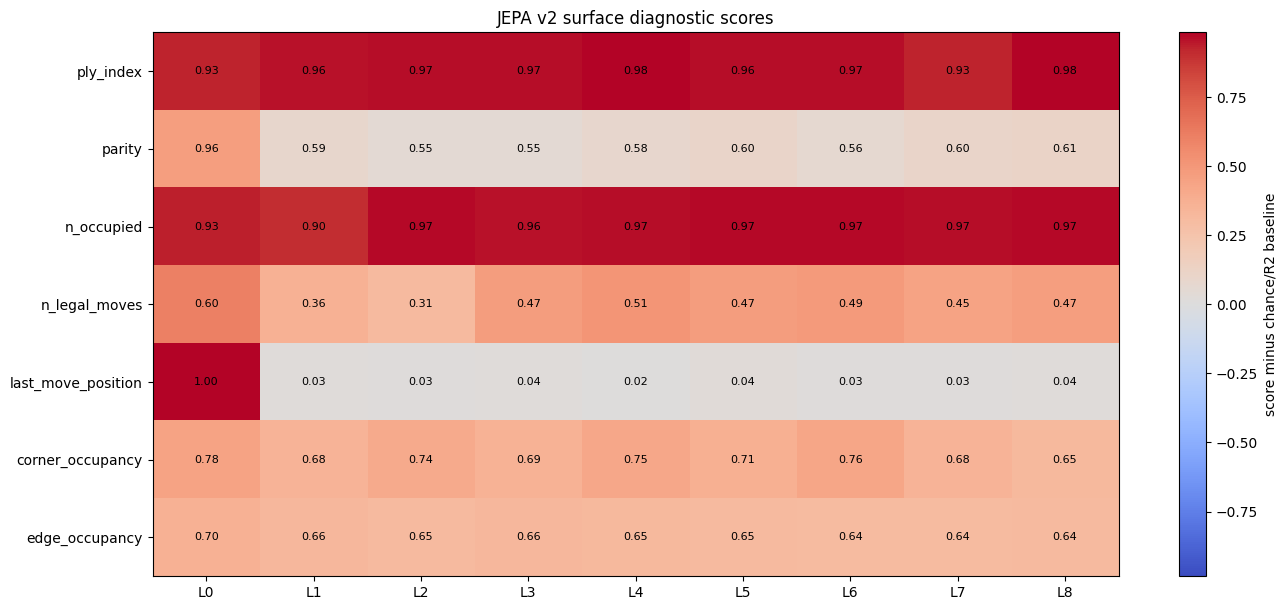

In [31]:
features = results['features']
layers = results['layers']
raw_scores = []
centered_scores = []
for feature in features:
    raw_row = []
    centered_row = []
    for layer in layers:
        item = results['metrics'][feature][str(layer)]
        score = float(item[item['metric']])
        selected = item['val'] if item.get('val') is not None else item['train']
        chance = float(selected.get('chance', 0.0))
        raw_row.append(score)
        centered_row.append(score - chance)
    raw_scores.append(raw_row)
    centered_scores.append(centered_row)

heat = torch.tensor(centered_scores).numpy()
raw = torch.tensor(raw_scores).numpy()
limit = max(abs(float(heat.min())), abs(float(heat.max())), 1e-6)

plt.figure(figsize=(1.2 * len(layers) + 3, 0.6 * len(features) + 2))
im = plt.imshow(heat, cmap='coolwarm', vmin=-limit, vmax=limit, aspect='auto')
plt.colorbar(im, label='score minus chance/R2 baseline')
plt.xticks(range(len(layers)), [f'L{layer}' for layer in layers])
plt.yticks(range(len(features)), features)
for i in range(len(features)):
    for j in range(len(layers)):
        plt.text(j, i, f'{raw[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('JEPA v2 surface diagnostic scores')
plt.tight_layout()
plt.show()

## 12. Linear vs MLP Surface Probes at the Final Layer

The next-move / legal-move head reads from the **final encoder layer**
(`layer_evaluated = "all token positions from final encoder layer"`), yet the
linear surface diagnostics show `ply_index` / `n_occupied` collapsing to large
negative R^2 in the deep layers. That tells us the temporal signal is not
*linearly* present at the layer the head actually uses — it does **not** tell us
whether the signal is gone or merely encoded non-linearly.

These two cells settle it. For the final layer (and, for context, the best
linear layer L1) we train **both** a linear probe and a small **MLP** probe on
the same activations and the same surface features. The comparison:

- **MLP >> linear at L_final** -> the temporal/surface signal is *present but
  non-linearly encoded*. The legal-move head (an MLP) can exploit it: the
  shortcut hypothesis survives, just in non-linear form.
- **MLP ~= linear ~= baseline at L_final** -> the signal is genuinely absent at
  the head's input. The legal accuracy must come from something the surface
  diagnostics do not capture (e.g. move-plausibility encoding), not from a
  temporal shortcut.


In [32]:
# --- Probe with swappable model: linear vs MLP, IDENTICAL training/eval path. ---
# This is train_linear_probe copied verbatim from othello_research.probes.surface_features,
# with the SINGLE change that the model can be 'linear' or 'mlp'. Optimizer (AdamW),
# epochs/lr/weight_decay (from probe_cfg), target standardization, loss, and the
# production metric functions are all reused unchanged.

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from othello_research.probes.surface_features import (
    _collect_probe_dataset, _resolve_feature_spec, _resolve_device,
    _regression_metrics, _classification_metrics, _multi_classification_metrics,
)

N_BLOCKS = len(encoder.blocks)
PROBE_LAYERS = tuple(sorted({1, N_BLOCKS}))
PROBE_FEATURES = ('ply_index', 'n_occupied', 'n_legal_moves', 'parity',
                  'corner_occupancy', 'edge_occupancy')
MLP_HIDDEN = 256


def _build_model(kind, d_model, out_dim):
    if kind == 'linear':
        return nn.Linear(d_model, out_dim)
    return nn.Sequential(
        nn.Linear(d_model, MLP_HIDDEN), nn.ReLU(),
        nn.Linear(MLP_HIDDEN, out_dim),
    )


def train_probe(activations, labels, spec, cfg, kind,
                *, val_activations=None, val_labels=None):
    """Verbatim copy of train_linear_probe; only the model constructor differs."""
    device = _resolve_device(cfg.device)
    probe_type = str(spec["type"])
    d_model = int(activations.size(1))

    if probe_type == "regression":
        out_dim = int(spec.get("out_dim", 1))
        model = _build_model(kind, d_model, out_dim).to(device)
        y_train = labels.float().view(-1, out_dim)
        target_mean = y_train.mean(dim=0, keepdim=True)
        target_std = y_train.std(dim=0, unbiased=False, keepdim=True).clamp_min(1e-6)
        train_targets = (y_train - target_mean) / target_std
    elif probe_type in {"binary", "classification"}:
        out_dim = int(spec["out_dim"])
        model = _build_model(kind, d_model, out_dim).to(device)
        train_targets = labels.long().view(-1)
    elif probe_type == "multi_classification":
        groups = int(spec["groups"]); classes = int(spec["classes_per_group"])
        model = _build_model(kind, d_model, groups * classes).to(device)
        train_targets = labels.long()
    else:
        raise ValueError(f"Unsupported probe type: {probe_type}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    dataset = TensorDataset(activations.float(), train_targets)
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)

    for _epoch in range(cfg.epochs):
        model.train()
        for x_cpu, y_cpu in loader:
            x = x_cpu.to(device); y = y_cpu.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            if probe_type == "regression":
                loss = F.mse_loss(logits, y)
            elif probe_type in {"binary", "classification"}:
                loss = F.cross_entropy(logits, y)
            else:
                groups = int(spec["groups"]); classes = int(spec["classes_per_group"])
                loss = F.cross_entropy(logits.view(-1, groups, classes).reshape(-1, classes), y.reshape(-1))
            loss.backward()
            optimizer.step()

    if probe_type == "regression":
        val_metrics = _regression_metrics(model, val_activations.float(), val_labels,
                                          device, target_mean, target_std)
        metric_name = "r2"
    elif probe_type in {"binary", "classification"}:
        val_metrics = _classification_metrics(model, val_activations.float(), val_labels, spec, device)
        metric_name = "accuracy"
    else:
        val_metrics = _multi_classification_metrics(model, val_activations.float(), val_labels, spec, device)
        metric_name = "accuracy"
    return metric_name, float(val_metrics[metric_name])


# Rebuild activations exactly as the production pipeline does (batched + padded),
# reusing the exact samples drawn in the baseline cell.
print('collecting probe dataset (production-consistent)...')
train_acts, train_labels_d = _collect_probe_dataset(
    encoder, baseline_train_samples, BOARD_SIZE, PROBE_LAYERS, PROBE_FEATURES,
    batch_size=256, device=device, desc='train')
val_acts, val_labels_d = _collect_probe_dataset(
    encoder, baseline_val_samples, BOARD_SIZE, PROBE_LAYERS, PROBE_FEATURES,
    batch_size=256, device=device, desc='val')
print('  shapes:', {L: tuple(t.shape) for L, t in train_acts.items()})

torch.manual_seed(0)
final_probe_results = {}
for feature in PROBE_FEATURES:
    spec = _resolve_feature_spec(FEATURE_SPECS[feature], BOARD_SIZE)
    final_probe_results[feature] = {}
    for layer in PROBE_LAYERS:
        d = {}
        for kind in ('linear', 'mlp'):
            metric, score = train_probe(
                train_acts[layer], train_labels_d[feature], spec, probe_cfg, kind,
                val_activations=val_acts[layer], val_labels=val_labels_d[feature])
            d[kind] = (metric, score)
        final_probe_results[feature][layer] = d
print('linear vs MLP probes complete (single difference: the model)')

collecting probe dataset (production-consistent)...


train:   0%|          | 0/79 [00:00<?, ?batch/s]

val:   0%|          | 0/8 [00:00<?, ?batch/s]

  shapes: {1: (20000, 512), 8: (20000, 512)}
linear vs MLP probes complete (single difference: the model)


feature             metric     baseline   lin L1   mlp L1   lin L8   mlp L8  mlp-lin@final
------------------------------------------------------------------------------------------
ply_index           r2           -0.000    0.964    0.978    0.979    0.997          0.019
n_occupied          r2           -0.000    0.939    0.978    0.978    0.998          0.020
n_legal_moves       r2           -0.000   -0.846    0.448    0.470    0.076         -0.394
parity              accuracy      0.504    0.614    0.816    0.581    0.708          0.127
corner_occupancy    accuracy      0.754    0.734    0.757    0.728    0.766          0.038
edge_occupancy      accuracy      0.644    0.660    0.693    0.675    0.694          0.019

Reading:
  mlp L8 >> lin L8 (and >> baseline) -> signal present but NON-LINEAR
                                       at the head input: temporal shortcut survives.
  mlp L8 ~= lin L8 ~= baseline       -> signal genuinely ABSENT at head
                                  

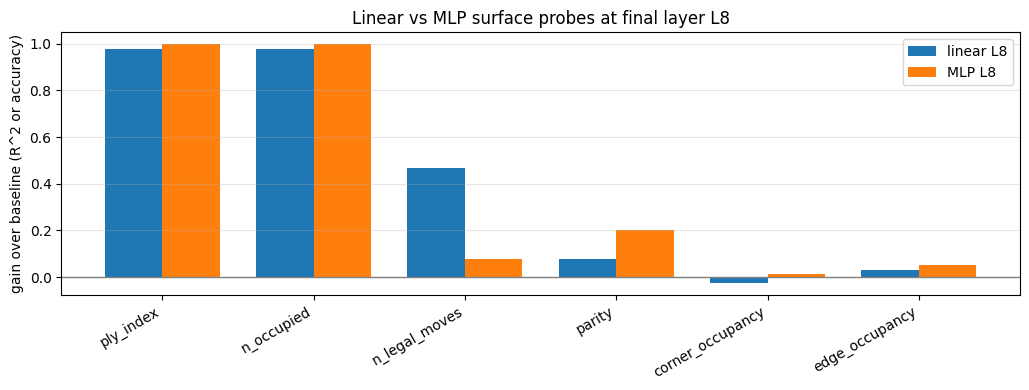

In [33]:
# --- Report: does an MLP recover surface signal the linear probe missed? --- without hard disjoint
L_final = N_BLOCKS
hdr = ('feature'.ljust(20) + 'metric'.ljust(9) + 'baseline'.rjust(10)
       + 'lin L1'.rjust(9) + 'mlp L1'.rjust(9)
       + f'lin L{L_final}'.rjust(9) + f'mlp L{L_final}'.rjust(9)
       + 'mlp-lin@final'.rjust(15))
print(hdr); print('-' * len(hdr))
for feature in PROBE_FEATURES:
    metric = baseline_results[feature]['metric']
    base = float(baseline_results[feature][metric])
    lin1 = final_probe_results[feature][1]['linear'][1]
    mlp1 = final_probe_results[feature][1]['mlp'][1]
    linf = final_probe_results[feature][L_final]['linear'][1]
    mlpf = final_probe_results[feature][L_final]['mlp'][1]
    print(feature.ljust(20) + metric.ljust(9)
          + f'{base:10.3f}' + f'{lin1:9.3f}' + f'{mlp1:9.3f}'
          + f'{linf:9.3f}' + f'{mlpf:9.3f}' + f'{mlpf - linf:15.3f}')

print()
print('Reading:')
print(f'  mlp L{L_final} >> lin L{L_final} (and >> baseline) -> signal present but NON-LINEAR')
print(f'                                       at the head input: temporal shortcut survives.')
print(f'  mlp L{L_final} ~= lin L{L_final} ~= baseline       -> signal genuinely ABSENT at head')
print(f'                                       input: legal accuracy is not a temporal shortcut.')

import numpy as np
feats = list(PROBE_FEATURES)
lin_gain, mlp_gain = [], []
for feature in feats:
    metric = baseline_results[feature]['metric']
    base = float(baseline_results[feature][metric])
    lin_gain.append(final_probe_results[feature][L_final]['linear'][1] - base)
    mlp_gain.append(final_probe_results[feature][L_final]['mlp'][1] - base)
xpos = np.arange(len(feats)); w = 0.38
plt.figure(figsize=(1.4 * len(feats) + 2, 4))
plt.bar(xpos - w/2, lin_gain, w, label=f'linear L{L_final}')
plt.bar(xpos + w/2, mlp_gain, w, label=f'MLP L{L_final}')
plt.axhline(0, color='gray', lw=1)
plt.xticks(xpos, feats, rotation=30, ha='right')
plt.ylabel('gain over baseline (R^2 or accuracy)')
plt.title(f'Linear vs MLP surface probes at final layer L{L_final}')
plt.legend(); plt.grid(True, axis='y', alpha=0.3); plt.tight_layout(); plt.show()

feature             metric     baseline   lin L1   mlp L1   lin L8   mlp L8  mlp-lin@final
------------------------------------------------------------------------------------------
ply_index           r2           -0.000    0.964    0.978    0.979    0.997          0.019
n_occupied          r2           -0.000    0.939    0.978    0.978    0.998          0.020
n_legal_moves       r2           -0.000   -0.846    0.448    0.470    0.076         -0.394
parity              accuracy      0.504    0.614    0.816    0.581    0.708          0.127
corner_occupancy    accuracy      0.754    0.734    0.757    0.728    0.766          0.038
edge_occupancy      accuracy      0.644    0.660    0.693    0.675    0.694          0.019

Reading:
  mlp L8 >> lin L8 (and >> baseline) -> signal present but NON-LINEAR
                                       at the head input: temporal shortcut survives.
  mlp L8 ~= lin L8 ~= baseline       -> signal genuinely ABSENT at head
                                  

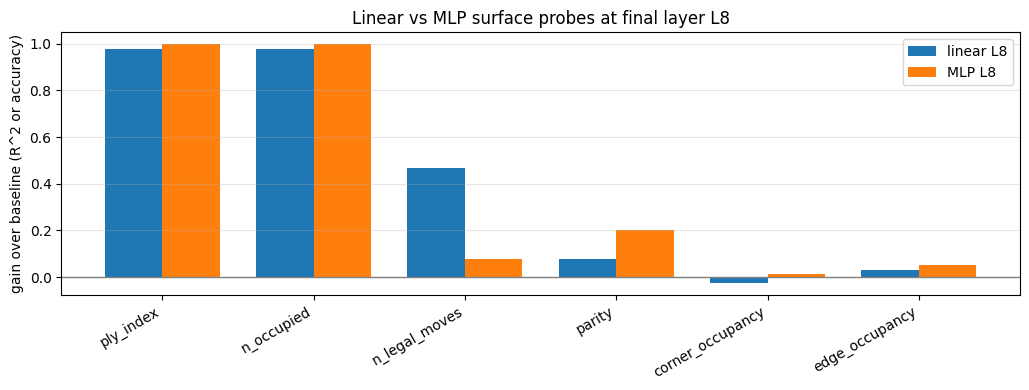

In [34]:
# --- Report: does an MLP recover surface signal the linear probe missed? --- for hard disjoint cases
L_final = N_BLOCKS
hdr = ('feature'.ljust(20) + 'metric'.ljust(9) + 'baseline'.rjust(10)
       + 'lin L1'.rjust(9) + 'mlp L1'.rjust(9)
       + f'lin L{L_final}'.rjust(9) + f'mlp L{L_final}'.rjust(9)
       + 'mlp-lin@final'.rjust(15))
print(hdr); print('-' * len(hdr))
for feature in PROBE_FEATURES:
    metric = baseline_results[feature]['metric']
    base = float(baseline_results[feature][metric])
    lin1 = final_probe_results[feature][1]['linear'][1]
    mlp1 = final_probe_results[feature][1]['mlp'][1]
    linf = final_probe_results[feature][L_final]['linear'][1]
    mlpf = final_probe_results[feature][L_final]['mlp'][1]
    print(feature.ljust(20) + metric.ljust(9)
          + f'{base:10.3f}' + f'{lin1:9.3f}' + f'{mlp1:9.3f}'
          + f'{linf:9.3f}' + f'{mlpf:9.3f}' + f'{mlpf - linf:15.3f}')

print()
print('Reading:')
print(f'  mlp L{L_final} >> lin L{L_final} (and >> baseline) -> signal present but NON-LINEAR')
print(f'                                       at the head input: temporal shortcut survives.')
print(f'  mlp L{L_final} ~= lin L{L_final} ~= baseline       -> signal genuinely ABSENT at head')
print(f'                                       input: legal accuracy is not a temporal shortcut.')

import numpy as np
feats = list(PROBE_FEATURES)
lin_gain, mlp_gain = [], []
for feature in feats:
    metric = baseline_results[feature]['metric']
    base = float(baseline_results[feature][metric])
    lin_gain.append(final_probe_results[feature][L_final]['linear'][1] - base)
    mlp_gain.append(final_probe_results[feature][L_final]['mlp'][1] - base)
xpos = np.arange(len(feats)); w = 0.38
plt.figure(figsize=(1.4 * len(feats) + 2, 4))
plt.bar(xpos - w/2, lin_gain, w, label=f'linear L{L_final}')
plt.bar(xpos + w/2, mlp_gain, w, label=f'MLP L{L_final}')
plt.axhline(0, color='gray', lw=1)
plt.xticks(xpos, feats, rotation=30, ha='right')
plt.ylabel('gain over baseline (R^2 or accuracy)')
plt.title(f'Linear vs MLP surface probes at final layer L{L_final}')
plt.legend(); plt.grid(True, axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 12. AR Transformer Surface Diagnostics

This runs the same probes on the AR Transformer baseline (`run_001`) using the same chunks, sampled positions, features, layers, and linear-probe hyperparameters. This is the key control for deciding whether JEPA v2 is specifically weak relative to the autoregressive baseline.


In [35]:
from othello_research.models.gpt import GPTConfig, OthelloGPT

AR_RUN_NAME = 'run_001'
AR_RUN_CANDIDATES = [
    PROJECT_ROOT / 'runs' / AR_RUN_NAME,
    ARTIFACT_ROOT / 'runs' / AR_RUN_NAME,
]
AR_OUT_DIR = next((p for p in AR_RUN_CANDIDATES if p.exists()), AR_RUN_CANDIDATES[0])
assert AR_OUT_DIR.exists(), AR_OUT_DIR

ar_checkpoint_files = sorted(AR_OUT_DIR.glob('*.pt'))
print('AR checkpoint dir:', AR_OUT_DIR)
print('Available AR checkpoint files:')
for path in ar_checkpoint_files:
    print(' ', path.name)

AR_CHECKPOINT_NAME = 'final.pt'
AR_CHECKPOINT_PATH = AR_OUT_DIR / AR_CHECKPOINT_NAME
if not AR_CHECKPOINT_PATH.exists():
    assert ar_checkpoint_files, f'No AR checkpoint files found in {AR_OUT_DIR}'
    AR_CHECKPOINT_PATH = ar_checkpoint_files[-1]
print('Selected AR checkpoint:', AR_CHECKPOINT_PATH)

# Free JEPA weights before loading AR to reduce T4 VRAM pressure.
try:
    del jepa_model
    del encoder
    if device.type == 'cuda':
        torch.cuda.empty_cache()
except NameError:
    pass

ar_ckpt = torch.load(AR_CHECKPOINT_PATH, map_location=device)
ar_cfg = GPTConfig(**ar_ckpt['model_config'])
ar_model = OthelloGPT(ar_cfg)
ar_model.load_state_dict(ar_ckpt['model'])
ar_model.to(device)
ar_model.eval()

print('AR checkpoint:', AR_CHECKPOINT_PATH.name)
print('AR step      :', ar_ckpt.get('step'))
print('AR games_seen:', f"{ar_ckpt.get('games_seen', 0):,}")
print('AR params    :', f"{sum(p.numel() for p in ar_model.parameters()):,}")


AR checkpoint dir: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/run_001
Available AR checkpoint files:
  checkpoint_games_001M.pt
  checkpoint_games_005M.pt
  checkpoint_games_010M.pt
  checkpoint_games_015M.pt
  final.pt
  latest.pt
Selected AR checkpoint: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/run_001/final.pt
AR checkpoint: final.pt
AR step      : 78200
AR games_seen: 19,999,840
AR params    : 25,312,768


In [36]:
ar_results = run_surface_diagnostics(
    encoder=ar_model,
    train_chunks=train_chunks,
    val_chunks=val_chunks,
    board_size=BOARD_SIZE,
    n_train_games=DIAG_TRAIN_GAMES,
    n_val_games=DIAG_VAL_GAMES,
    layers=DIAG_LAYERS,
    features=DIAG_FEATURES,
    sample_positions=DIAG_SAMPLE_POSITIONS,
    probe_cfg=probe_cfg,
    device=str(device),
)
ar_results['baselines'] = baseline_results
print('AR diagnostics complete')


collect train activations:   0%|          | 0/79 [00:00<?, ?batch/s]

collect val activations:   0%|          | 0/8 [00:00<?, ?batch/s]

train linear probes:   0%|          | 0/63 [00:00<?, ?probe/s]

AR diagnostics complete


feature                  metric       baseline  JEPA best   JEPA L    AR best     AR L    AR-JEPA
--------------------------------------------------------------------------------------------------
ply_index                r2             -0.000      0.977       L4      1.000       L0      0.022
parity                   accuracy        0.504      0.964       L0      0.993       L1      0.029
n_occupied               r2             -0.000      0.972       L8      1.000       L0      0.028
n_legal_moves            r2             -0.000      0.600       L0      0.898       L7      0.298
last_move_position       accuracy        0.015      1.000       L0      1.000       L0      0.000
corner_occupancy         accuracy        0.754      0.778       L0      0.992       L4      0.214
edge_occupancy           accuracy        0.644      0.702       L0      0.989       L5      0.287


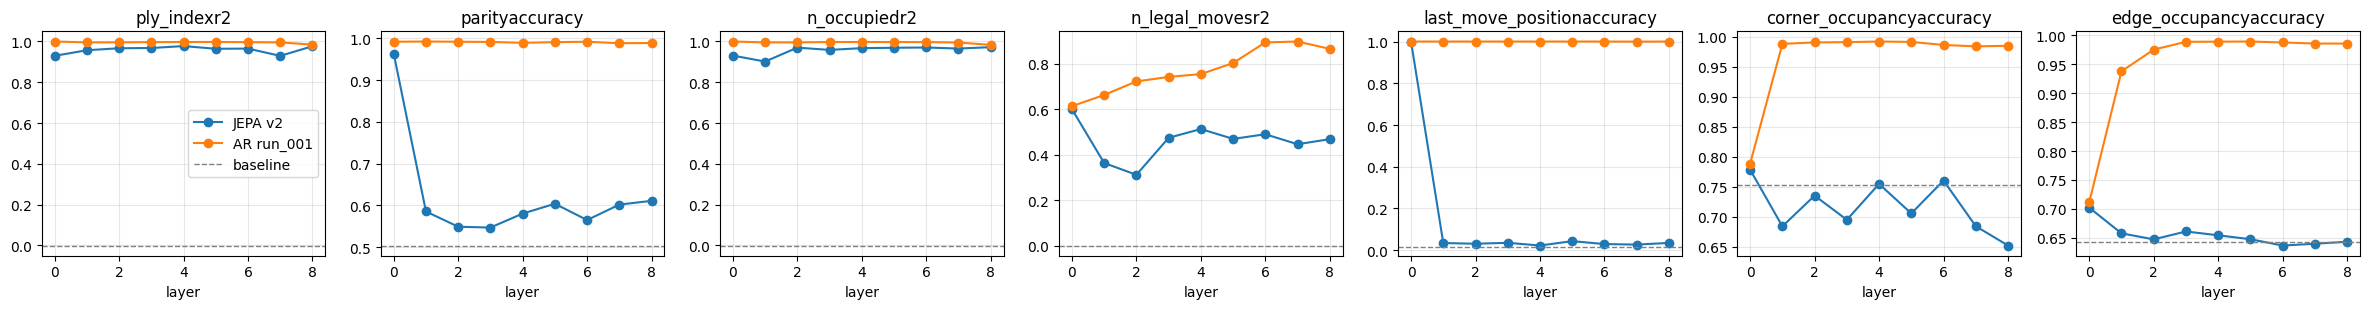

In [37]:
def ar_score_for(feature, layer):
    item = ar_results['metrics'][feature][str(layer)]
    return float(item[item['metric']])

print('feature'.ljust(24), 'metric'.ljust(10), 'baseline'.rjust(10), 'JEPA best'.rjust(10), 'JEPA L'.rjust(8), 'AR best'.rjust(10), 'AR L'.rjust(8), 'AR-JEPA'.rjust(10))
print('-' * 98)
for feature in DIAG_FEATURES:
    metric = baseline_results[feature]['metric']
    baseline_score = float(baseline_results[feature][metric])
    jepa_layer, jepa_best = max(
        ((layer, score_for(feature, layer)) for layer in results['layers']),
        key=lambda item: item[1],
    )
    ar_layer, ar_best = max(
        ((layer, ar_score_for(feature, layer)) for layer in ar_results['layers']),
        key=lambda item: item[1],
    )
    print(
        feature.ljust(24),
        metric.ljust(10),
        f'{baseline_score:10.3f}',
        f'{jepa_best:10.3f}',
        f'L{jepa_layer}'.rjust(8),
        f'{ar_best:10.3f}',
        f'L{ar_layer}'.rjust(8),
        f'{ar_best - jepa_best:10.3f}',
    )

fig, axes = plt.subplots(1, len(DIAG_FEATURES), figsize=(3.4 * len(DIAG_FEATURES), 3.2), sharey=False)
if len(DIAG_FEATURES) == 1:
    axes = [axes]
for ax, feature in zip(axes, DIAG_FEATURES):
    jepa_y = [score_for(feature, layer) for layer in results['layers']]
    ar_y = [ar_score_for(feature, layer) for layer in ar_results['layers']]
    metric = baseline_results[feature]['metric']
    baseline = float(baseline_results[feature][metric])
    ax.plot(results['layers'], jepa_y, marker='o', label='JEPA v2')
    ax.plot(ar_results['layers'], ar_y, marker='o', label='AR run_001')
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, label='baseline')
    ax.set_title(f'{feature}{metric}')
    ax.set_xlabel('layer')
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


In [38]:
ar_result_path = DIAG_OUT_DIR / f'surface_diagnostics__AR_{AR_RUN_NAME}__{AR_CHECKPOINT_PATH.stem}.json'
ar_result_path.write_text(json.dumps(ar_results, indent=2, default=str), encoding='utf-8')
print('saved AR diagnostics:', ar_result_path)


saved AR diagnostics: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v3_mlp_k8_b8_run_001/diagnostics/surface_diagnostics__AR_run_001__final.json


## 13. Save JEPA Results

In [39]:
results['baselines'] = baseline_results
result_path = DIAG_OUT_DIR / f'surface_diagnostics__{CHECKPOINT_PATH.stem}.json'
result_path.write_text(json.dumps(results, indent=2, default=str), encoding='utf-8')
print('saved JEPA diagnostics:', result_path)


saved JEPA diagnostics: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v3_mlp_k8_b8_run_001/diagnostics/surface_diagnostics__final.json


## 14. Brief Interpretation

After running the notebook, compare every learned score against the mean/majority baseline and against the AR baseline.

> If JEPA v2 only beats the majority baseline weakly on `corner_occupancy` / `edge_occupancy`, while AR strongly beats the same baselines across depth, this supports the shortcut hypothesis. Fill in the observed deltas after running: JEPA surface features {X}; JEPA state features over baseline {Y}; AR state features over baseline {Z}.


## 15. Automate Diagnostics for All Runs
This script loops through all run directories in `ARTIFACT_ROOT / 'runs'`, loads the final checkpoint, runs the diagnostics, and saves the results.

In [40]:
import os
import json
import torch
import gc
import othello_research.training.train_jepa as tjm
from othello_research.probes.surface_features import run_surface_diagnostics

runs_base_dir = ARTIFACT_ROOT / 'runs'
print(f"Scanning for runs in: {runs_base_dir}")

# Find all directories that contain a 'final.pt' checkpoint
run_dirs = [d for d in runs_base_dir.iterdir() if d.is_dir() and (d / 'final.pt').exists()]
print(f"Found {len(run_dirs)} runs with 'final.pt'.")

for run_dir in run_dirs:
    print(f"\n{'='*60}")
    print(f"Processing run: {run_dir.name}")
    print(f"{'='*60}")

    ckpt_path = run_dir / 'final.pt'

    try:
        # 1. Load Checkpoint and Model
        ckpt = torch.load(ckpt_path, map_location=device)

        # Check if it's an AR model (GPT) or JEPA
        if 'model_config' in ckpt and 'vocab_size' in ckpt['model_config']:
            print(f"Skipping AR model {run_dir.name} (This loop is configured for JEPA models).")
            continue

        jepa_model, jepa_cfg = tjm.build_model_from_checkpoint(ckpt)
        state = ckpt['model']

        try:
            jepa_model.load_state_dict(state)
        except RuntimeError as exc:
            # Handle legacy JEPA checkpoints
            if not any(key.startswith('encoder.') for key in state):
                raise
            encoder_state = {
                key.replace('encoder.', '', 1): value
                for key, value in state.items()
                if key.startswith('encoder.')
            }
            encoder = getattr(jepa_model, 'encoder', None)
            if encoder is None:
                encoder = jepa_model.context_encoder
            encoder.load_state_dict(encoder_state, strict=True)

        jepa_model.to(device)
        jepa_model.eval()

        encoder = getattr(jepa_model, 'encoder', None)
        if encoder is None:
            encoder = jepa_model.context_encoder
        encoder.to(device)
        encoder.eval()

        # 2. Run Diagnostics
        print(f"Running surface diagnostics...")
        run_results = run_surface_diagnostics(
            encoder=encoder,
            train_chunks=train_chunks,
            val_chunks=val_chunks,
            board_size=BOARD_SIZE,
            n_train_games=DIAG_TRAIN_GAMES,
            n_val_games=DIAG_VAL_GAMES,
            layers=DIAG_LAYERS,
            features=DIAG_FEATURES,
            sample_positions=DIAG_SAMPLE_POSITIONS,
            probe_cfg=probe_cfg,
            device=str(device),
        )

        # 3. Save Results
        diag_out_dir = run_dir / 'diagnostics'
        diag_out_dir.mkdir(parents=True, exist_ok=True)
        result_path = diag_out_dir / f'surface_diagnostics__final.json'

        # Add baselines (computed earlier in the notebook)
        run_results['baselines'] = baseline_results

        result_path.write_text(json.dumps(run_results, indent=2, default=str), encoding='utf-8')
        print(f"Saved diagnostics to: {result_path}")

        # Free memory to prevent OOM
        del jepa_model
        del encoder
        del ckpt
        del state
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error processing run {run_dir.name}: {e}")

print("\nAll runs processed successfully!")


Scanning for runs in: /content/drive/MyDrive/Master_Thesis_Artifacts/runs
Found 14 runs with 'final.pt'.

Processing run: run_001
Skipping AR model run_001 (This loop is configured for JEPA models).

Processing run: run_001_smoke
Skipping AR model run_001_smoke (This loop is configured for JEPA models).

Processing run: jepa_linear_b8_run_001
Running surface diagnostics...


collect train activations:   0%|          | 0/79 [00:00<?, ?batch/s]

collect val activations:   0%|          | 0/8 [00:00<?, ?batch/s]

train linear probes:   0%|          | 0/63 [00:00<?, ?probe/s]

Saved diagnostics to: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_linear_b8_run_001/diagnostics/surface_diagnostics__final.json

Processing run: jepa_transformer_b8_run_001
Running surface diagnostics...


...

Saved diagnostics to: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_no_predictor_k1_vicreg_b8_run_001_hard_disjoint/diagnostics/surface_diagnostics__final.json

Processing run: jepa_v4_multi_pos_mlp_k4_b8_run_001_hard_disjoint_vicreg
Running surface diagnostics...


collect train activations:   0%|          | 0/79 [00:00<?, ?batch/s]

collect val activations:   0%|          | 0/8 [00:00<?, ?batch/s]

train linear probes:   0%|          | 0/63 [00:00<?, ?probe/s]

Saved diagnostics to: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_v4_multi_pos_mlp_k4_b8_run_001_hard_disjoint_vicreg/diagnostics/surface_diagnostics__final.json

All runs processed successfully!
